In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torchvision.transforms import functional as TF
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.ToTensor()

mnist_train = MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 342kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.88MB/s]


In [4]:
images = []
labels = []

for img, label in mnist_train:
    if label in [1, 2]:
        images.append(img)
        labels.append(label)

images = torch.stack(images)
labels = torch.tensor(labels)
print(images.shape)

torch.Size([12700, 1, 28, 28])


In [5]:
angles = list(range(0, 360, 30))

rotated_images = []
digit_labels = []
rotation_labels = []

for img, label in zip(images, labels):
    
    for angle in angles:
        
        rotated = TF.rotate(img, angle)
        
        rotated_images.append(rotated)
        digit_labels.append(label)
        rotation_labels.append(angle)

rotated_images = torch.stack(rotated_images)
digit_labels = torch.tensor(digit_labels)
rotation_labels = torch.tensor(rotation_labels)

print(rotated_images.shape)

torch.Size([152400, 1, 28, 28])


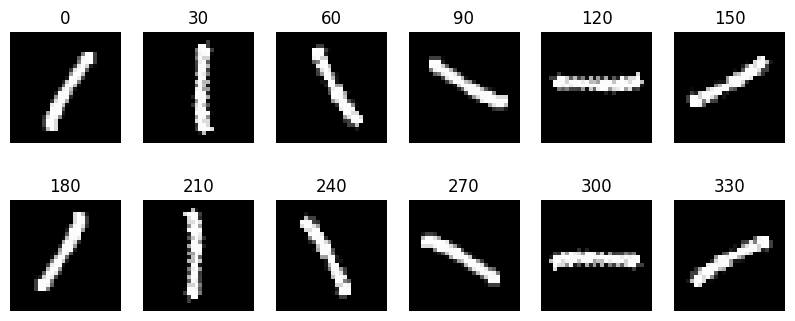

In [6]:
fig, ax = plt.subplots(2,6, figsize=(10,4))
sample = images[0]
for i, angle in enumerate(angles):
    r = TF.rotate(sample, angle)
    ax[i//6, i%6].imshow(r.squeeze(), cmap="gray")
    ax[i//6, i%6].set_title(angle)
    ax[i//6, i%6].axis("off")

plt.show()

In [7]:
class RotatedMNISTDataset(Dataset):
    def __init__(self, images):
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx]

In [8]:
dataset = RotatedMNISTDataset(rotated_images)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

In [10]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,4,stride=2,padding=1),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(64*7*7, latent_dim)
        self.fc_logvar = nn.Linear(64*7*7, latent_dim)

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim,64*7*7)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,stride=2,padding=1),
            nn.Sigmoid()
        )

    def forward(self,z):
        x = self.fc(z)
        x = x.view(-1,64,7,7)
        x = self.deconv(x)
        return x

In [11]:
class VAE(nn.Module):

    def __init__(self,latent_dim=16):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self,mu,logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self,x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu,logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [12]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(
        recon_x,
        x,
        reduction="sum"
    )
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    return recon_loss + kl_loss

latent_dim = 16
model = VAE(latent_dim).to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [13]:
torch.backends.cudnn.benchmark = True
epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(dataloader):
        batch = batch.to(device)
        recon, mu, logvar = model(batch)
        loss = vae_loss(recon, batch, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader.dataset)
    print(f"Epoch {epoch+1}/{epochs}  Loss: {avg_loss:.4f}")

100%|██████████| 1191/1191 [00:06<00:00, 179.13it/s]


Epoch 1/20  Loss: 124.2850


100%|██████████| 1191/1191 [00:04<00:00, 287.00it/s]


Epoch 2/20  Loss: 99.2291


100%|██████████| 1191/1191 [00:04<00:00, 283.91it/s]


...

Epoch 18/20  Loss: 89.5228


100%|██████████| 1191/1191 [00:04<00:00, 283.95it/s]


Epoch 19/20  Loss: 89.4289


100%|██████████| 1191/1191 [00:04<00:00, 287.66it/s]

Epoch 20/20  Loss: 89.3384


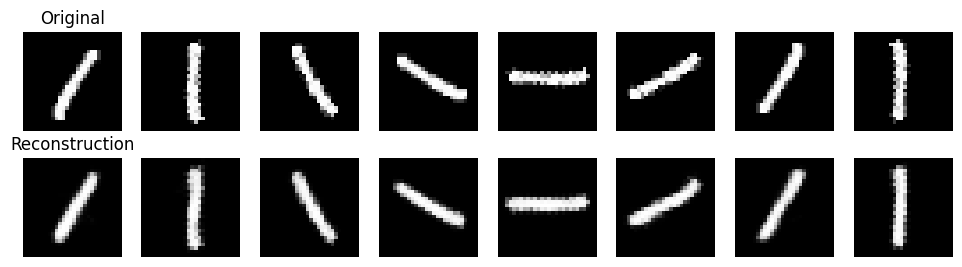

In [14]:
model.eval()
sample = rotated_images[:8].to(device)
with torch.no_grad():
    recon, _, _ = model(sample)

sample = sample.cpu()
recon = recon.cpu()

fig, ax = plt.subplots(2,8, figsize=(12,3))

for i in range(8):
    ax[0,i].imshow(sample[i].squeeze(), cmap="gray")
    ax[0,i].axis("off")
    ax[1,i].imshow(recon[i].squeeze(), cmap="gray")
    ax[1,i].axis("off")

ax[0,0].set_title("Original")
ax[1,0].set_title("Reconstruction")

plt.show()

In [15]:
model.eval()
latent_vectors = []
with torch.no_grad():
    for batch in tqdm(dataloader):
        batch = batch.to(device)
        mu, logvar = model.encoder(batch)
        z = mu
        latent_vectors.append(z.cpu())

latent_vectors = torch.cat(latent_vectors)

print("Latent vector shape:", latent_vectors.shape)

100%|██████████| 1191/1191 [00:01<00:00, 849.08it/s]


Latent vector shape: torch.Size([152400, 16])


In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

z_pca = pca.fit_transform(latent_vectors.numpy())

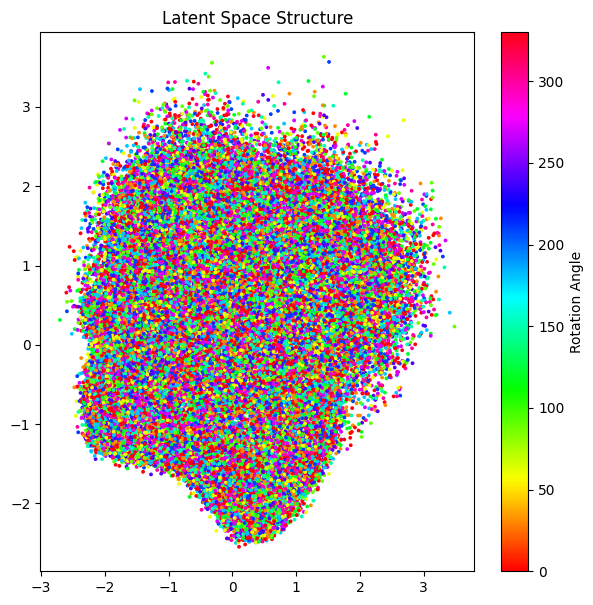

In [17]:
plt.figure(figsize=(7,7))

plt.scatter(
    z_pca[:,0],
    z_pca[:,1],
    c=rotation_labels.numpy(),
    cmap="hsv",
    s=3
)
plt.colorbar(label="Rotation Angle")
plt.title("Latent Space Structure")
plt.show()

In [18]:
angles = rotation_labels.numpy()

unique_angles = sorted(set(angles))

angle_to_class = {angle:i for i,angle in enumerate(unique_angles)}

rotation_classes = np.array([angle_to_class[a] for a in angles])

In [19]:
from torch.utils.data import TensorDataset

X = torch.tensor(latent_vectors).float()

y = torch.tensor(rotation_classes)

latent_dataset = TensorDataset(X, y)

latent_loader = DataLoader(
    latent_dataset,
    batch_size=256,
    shuffle=True
)

/tmp/ipykernel_55/3269782003.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(latent_vectors).float()


In [20]:
class RotationClassifier(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 12)
        )

    def forward(self, x):
        return self.net(x)

In [21]:
clf = RotationClassifier(latent_dim).to(device)
optimizer = torch.optim.Adam(clf.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [23]:
epochs = 20

for epoch in range(epochs):
    clf.train()
    total_loss = 0
    correct = 0
    total = 0
    for x_batch, y_batch in latent_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        preds = clf(x_batch)
        loss = criterion(preds, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        predicted = torch.argmax(preds, dim=1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
    acc = correct / total
    print(f"Epoch {epoch+1}, Loss {total_loss/len(latent_loader):.4f}, Accuracy {acc:.4f}")

Epoch 1, Loss 2.4817, Accuracy 0.0945
Epoch 2, Loss 2.4813, Accuracy 0.0959
Epoch 3, Loss 2.4805, Accuracy 0.0962
Epoch 4, Loss 2.4800, Accuracy 0.0968
Epoch 5, Loss 2.4795, Accuracy 0.0988
Epoch 6, Loss 2.4790, Accuracy 0.0983
Epoch 7, Loss 2.4785, Accuracy 0.1006
Epoch 8, Loss 2.4781, Accuracy 0.1000
Epoch 9, Loss 2.4777, Accuracy 0.1011
Epoch 10, Loss 2.4771, Accuracy 0.1015
Epoch 11, Loss 2.4768, Accuracy 0.1011
Epoch 12, Loss 2.4766, Accuracy 0.1022
Epoch 13, Loss 2.4762, Accuracy 0.1028
Epoch 14, Loss 2.4759, Accuracy 0.1035
Epoch 15, Loss 2.4757, Accuracy 0.1037
Epoch 16, Loss 2.4752, Accuracy 0.1037
Epoch 17, Loss 2.4748, Accuracy 0.1041
Epoch 18, Loss 2.4746, Accuracy 0.1043
Epoch 19, Loss 2.4743, Accuracy 0.1049
Epoch 20, Loss 2.4741, Accuracy 0.1050


In [24]:
torch.save(model.state_dict(), "vae_model.pth")
torch.save(latent_vectors, "latent_vectors.pt")
torch.save(digit_labels, "digit_labels.pt")
torch.save(rotation_labels, "rotation_labels.pt")

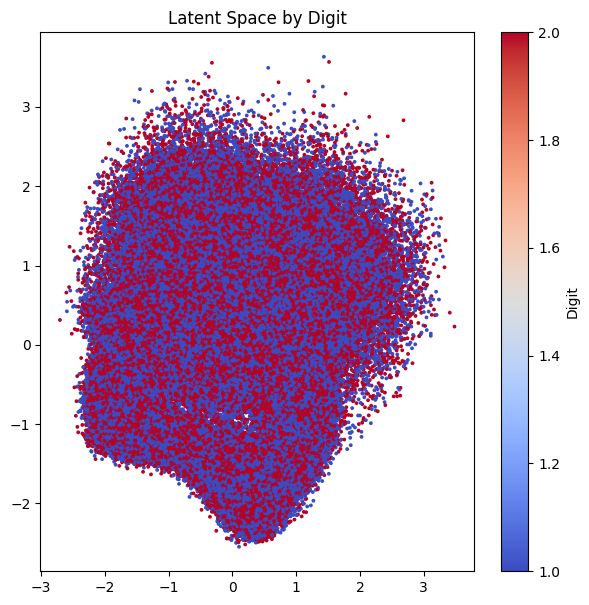

In [25]:
plt.figure(figsize=(7,7))

plt.scatter(
    z_pca[:,0],
    z_pca[:,1],
    c=digit_labels.numpy(),
    cmap="coolwarm",
    s=3
)

plt.colorbar(label="Digit")
plt.title("Latent Space by Digit")
plt.show()

In [28]:
rotation_steps = list(range(0,360,30))
sample_index = 0

trajectory = []
rotation_steps = list(range(0,360,30))
for angle in rotation_steps:
    img = TF.rotate(images[sample_index], float(angle)).unsqueeze(0).to(device)
    with torch.no_grad():
        mu, _ = model.encoder(img)
    trajectory.append(mu.cpu().numpy()[0])

trajectory = np.array(trajectory)

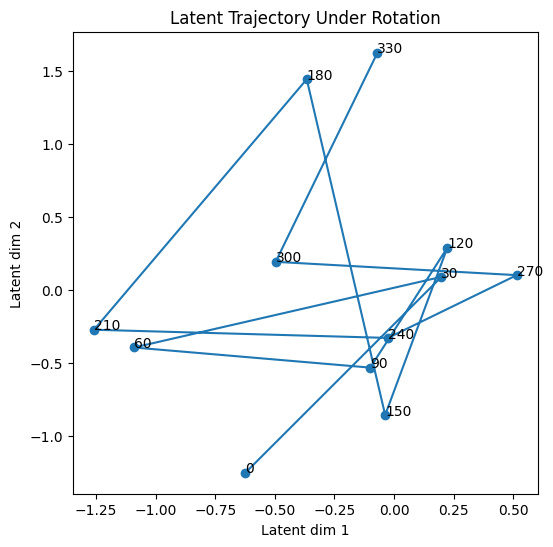

In [29]:
plt.figure(figsize=(6,6))

plt.plot(trajectory[:,0], trajectory[:,1], marker='o')

for i, angle in enumerate(rotation_steps):
    plt.text(trajectory[i,0], trajectory[i,1], str(angle))

plt.title("Latent Trajectory Under Rotation")
plt.xlabel("Latent dim 1")
plt.ylabel("Latent dim 2")

plt.show()

In [30]:
sample_index2 = 0
rotation_steps = list(range(0,360,30))

trajectory2 = []
for angle in rotation_steps:
    img = TF.rotate(images[sample_index2], float(angle)).unsqueeze(0).to(device)

    with torch.no_grad():
        mu, _ = model.encoder(img)

    trajectory2.append(mu.cpu().numpy()[0])

trajectory2 = np.array(trajectory2)

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

trajectory_pca = pca.fit_transform(trajectory2)

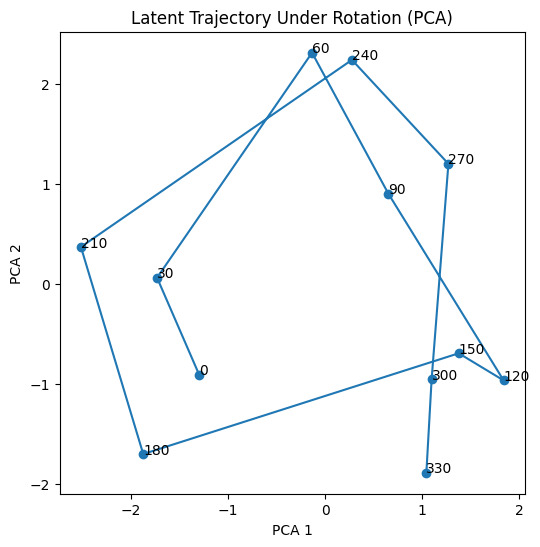

In [32]:
plt.figure(figsize=(6,6))

plt.plot(
    trajectory_pca[:,0],
    trajectory_pca[:,1],
    marker="o"
)

for i,angle in enumerate(rotation_steps):

    plt.text(
        trajectory_pca[i,0],
        trajectory_pca[i,1],
        str(angle)
    )

plt.title("Latent Trajectory Under Rotation (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()